## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Spring 2025)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**84**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (35 points)

Suppose you have two satellites orbiting Earth.  The [Clohessy-Wiltshire equations](https://en.wikipedia.org/wiki/Clohessy%E2%80%93Wiltshire_equations#cite_note-3) describe the position of one satellite with respect to the other. After making some assumptions, they are given in two dimensions by the following equations:

$$ \frac{dx}{dt} = a $$
$$ \frac{dy}{dt} = b $$
$$ \frac{da}{dt} = 3(0.00113)^{2}x + 2(0.00113)b $$
$$ \frac{db}{dt} = -2(0.00113)a $$

where $x$ and $y$ describe the position and $a$ and $b$ describe the velocities.

### **Part 1.1 (25 points)**: 
Solve this system using `solve_ivp`. Assuming the following initial conditions (taken from [here](http://dx.doi.org/10.15282/ijame.9.2013.28.0150)):

* $x(0) = 0.0$
* $y(0) = 1.0$
* $a(0) = 0.0005785$
* $b(0) = 0.0$

Evolve the model from $t=0$ to $t=6000$ using a timestep of $\Delta t = 10 $.

**Code you need to write to solve this problem**:
* (5 pts) A function that takes in a set of time values as well as the current values for $x$, $y$, $a$, and $b$ and **returns** the derivatives for each variable, $\frac{dx}{dt}$, $\frac{dy}{dt}$, $\frac{da}{dt}$, and $\frac{db}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* (5 pts) A set of variables for storing your initial conditions, $x_0$, $y_0$, $a_0$, and $b_0$, set to the correct initial values.
* (5 pts) A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* (5 pts) Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* (5 pts) Code that unpacks the solution so that you can plot it.

**Note**: you will not need the "`args`" argument for `solve_ivp` for this case because any model parameters that might be needed for this system are provided directly as numbers in the set of  ODEs include above.

In [8]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [34]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals):
    x, y, a, b = vals
    n = 0.00113
    dxdt = a
    dydt = b
    dadt = 3*n**2*x + 2*n*b
    dbdt = -2*n*a
    return dxdt, dydt, dadt, dbdt

# Solve the system
x0 = 0.0
y0 = 1.0
a0 = 0.5785e-3
b0 = 0
ICs = [x0, y0, a0, b0]
t = np.arange(0, 6000, 10)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t)
x = sol.y[0,:]
y = sol.y[1,:]

# rubric
# 5 pts derivatives function
# 5 pts initial conditions
# 5 pts time array
# 5 pts proper call to solve_ivp
# 5 pts unpack solution

### **Part 1.2 (10 points)**:
Now that you have a solution to the model, make two plots:
* A graph that plots $x$ and $y$ against time
* A graph that plots $y$ against $x$

If all goes well, you should end up with something that looks like this.  Be sure to include axis labels and an appropriate legend!

**Note:** Even if your results from `solve_ivp` are wrong, you can still get partial credit for the plotting.

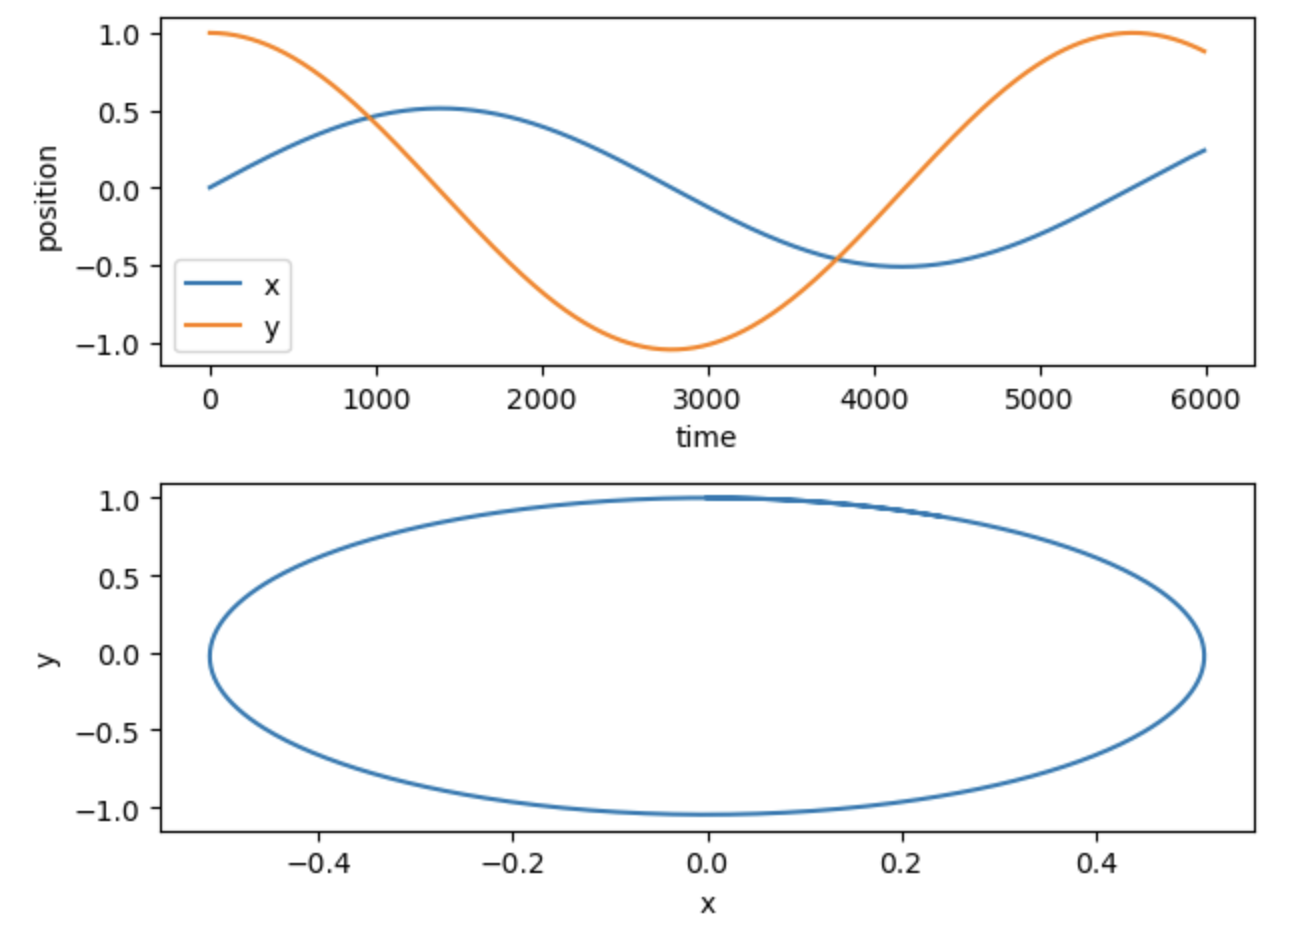

In [11]:
# put your code here

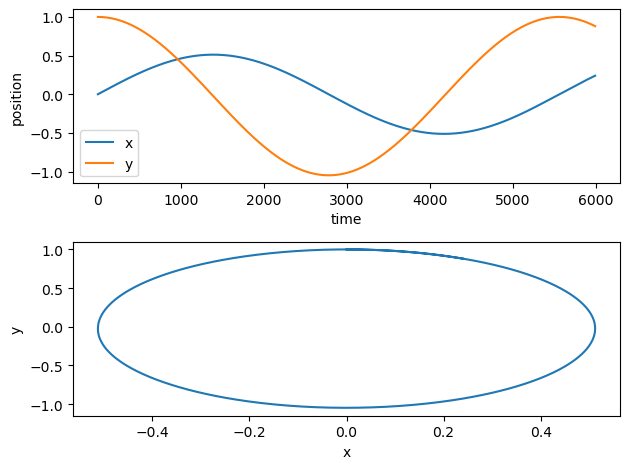

In [26]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

plt.subplot(2,1,1)
plt.plot(t,x,label='x')
plt.plot(t,y,label='y')
plt.xlabel('time')
plt.ylabel('position')
plt.legend()

plt.subplot(2,1,2)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()

# rubric
# 2pts plot x vs. time
# 2pts plot y vs. time
# 2pts plot x vs. y
# 2pts axis labels
# 2pts legend

## Part 2: Data Visualization (39 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, **choose three visualizations** to assess through the following questions.

For each visualization of your choosing, answer the following questions **in detail** (more than `yes` or `no`):

	(1) Does the plot tell a story? If so, what is it saying? (6 pts per visualization)
    (2) Does it use multi-variable data (more than two variables)? (3 pts per visualization)
	(3) Is there excessive white space or cluttering? (1 pts per visualization)
	(4) Are plot components appropriately labeled (legend, axes, title, etc)? (1 pt per visualization)
	(5) Describe one way the plot could be improved. (2 pts per visualization)

There are markdown cells provided for your convenience after each image so you don't have to keep scrolling!

### Visualizations to Choose From

**Visualization 1**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_HomePriceIncome.jpg?raw=true" width=500>

**Answers to questions about visualization 1:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_HousePrice.jpg?raw=true" width=500>

**Answers to questions about visualization 2:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


**Visualization 3**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/LandMassLongitude.jpg?raw=true" width=500>

**Answers to questions about visualization 3:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/AISentiment.jpg?raw=true" width=500>

**Answers to questions about visualization 4:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


**Visualization 5**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Housing-Market-Price-Changes.jpg?raw=true" width=500>

**Answers to questions about visualization 5:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


**Visualization 6**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Import_Dependence_on_China.jpg?raw=true" width=500>

**Answers to questions about visualization 6:**

 <font size="+3">&#9998;</font> 
 
1. Does the plot tell a story? If so, what is it saying?
2. Does it use multi-variable data (more than two variables)?
3. Is there excessive white space or cluttering?
4. Are plot components appropriately labeled (legend, axes, title, etc)?
5. Describe one way the plot could be improved.


### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations and add your favorite bad visualizations!

